In [1]:
import torch
import torch.nn.functional as F
from diffusers import UNet2DModel
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import CIFAR10, CIFAR100, MNIST, STL10
import torchvision.transforms as T
from pathlib import Path
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Dataset

In [2]:
DATASET = "mnist"

# --------------------------------------------------
# Transforms
# --------------------------------------------------

if DATASET == "mnist":

    tfm = T.Compose([
        T.Resize((32, 32)),
        T.Grayscale(num_output_channels=3),
        T.ToTensor(),
        T.Normalize(
            mean=(0.5, 0.5, 0.5),
            std=(0.5, 0.5, 0.5),
        ),
    ])

elif DATASET in ["cifar10", "cifar100"]:

    tfm = T.Compose([
        T.ToTensor(),
        T.Normalize(
            mean=(0.5, 0.5, 0.5),
            std=(0.5, 0.5, 0.5),
        ),
    ])

elif DATASET == "stl10":

    tfm = T.Compose([
        T.Resize((32, 32)),
        T.ToTensor(),
        T.Normalize(
            mean=(0.5, 0.5, 0.5),
            std=(0.5, 0.5, 0.5),
        ),
    ])


# --------------------------------------------------
# Dataset
# --------------------------------------------------

if DATASET == "cifar100":

    dataset = CIFAR100(
        root="datasets/cifar100/",
        train=True,
        download=True,
        transform=tfm,
    )

    test_set = CIFAR100(
        root="datasets/cifar100/",
        train=False,
        download=True,
        transform=tfm,
    )

elif DATASET == "cifar10":

    dataset = CIFAR10(
        root="datasets/cifar10/",
        train=True,
        download=True,
        transform=tfm,
    )

    test_set = CIFAR10(
        root="datasets/cifar10/",
        train=False,
        download=True,
        transform=tfm,
    )

elif DATASET == "stl10":

    dataset = STL10(
        root="datasets/stl10/",
        split="train",
        download=True,
        transform=tfm,
    )

    test_set = STL10(
        root="datasets/stl10/",
        split="test",
        download=True,
        transform=tfm,
    )

elif DATASET == "mnist":

    dataset = MNIST(
        root="datasets/mnist/",
        train=True,
        download=True,
        transform=tfm,
    )

    test_set = MNIST(
        root="datasets/mnist/",
        train=False,
        download=True,
        transform=tfm,
    )

### Model

In [ ]:
# --------------------------------------------------
# Model
# --------------------------------------------------

model = UNet2DModel(
    sample_size=32,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 256),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
).to(device)

### Utils

In [ ]:

# --------------------------------------------------
# Continuous VP diffusion
#
# dx = -1/2 beta(t) x dt + sqrt(beta(t)) dW
#
# beta(t) = beta_min + t (beta_max - beta_min)
# --------------------------------------------------

beta_min = 0.1
beta_max = 20.0


def vp_alpha_sigma(t):
    """
    t: shape (B,), with t in [0, 1]

    Returns:
        alpha(t), sigma(t), each shape (B,)
    """

    log_alpha = (
        -0.5 * beta_min * t
        -0.25 * (beta_max - beta_min) * t**2
    )

    alpha = torch.exp(log_alpha)
    sigma = torch.sqrt(1.0 - alpha**2)

    return alpha, sigma


def add_vp_noise(x0, t):
    """
    x_t = alpha(t) x_0 + sigma(t) eps
    """

    eps = torch.randn_like(x0)

    alpha, sigma = vp_alpha_sigma(t)

    alpha = alpha[:, None, None, None]
    sigma = sigma[:, None, None, None]

    xt = alpha * x0 + sigma * eps

    return xt, eps




In [ ]:
#model.load_state_dict(torch.load(f"trained_models/unet_{DATASET}_num_epochs=50.pt", map_location=device))

### Train

In [ ]:
# --------------------------------------------------
# Optimizer
# --------------------------------------------------

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
)

In [ ]:
# --------------------------------------------------
# Training
# --------------------------------------------------

train_loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)

num_epochs = 50

model.train()

for epoch in range(num_epochs):

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}")

    for batch in pbar:

        x0 = batch[0].to(device)

        B = x0.shape[0]

        # Continuous diffusion time t ~ Uniform(0, 1)
        t = torch.rand(
            B,
            device=device,
        )

        # Gaussian noise
        noise = torch.randn_like(x0)

        # VP coefficients
        alpha, sigma = vp_alpha_sigma(t)

        alpha = alpha[:, None, None, None]
        sigma = sigma[:, None, None, None]

        # x_t = alpha(t) x_0 + sigma(t) eps
        xt = alpha * x0 + sigma * noise

        # Scale t for the default diffusers time embedding
        t_model = 1000.0 * t

        # Predict the clean image directly:
        # x_theta(x_t, t) ~ x_0
        x0_pred = model(
            xt,
            t_model,
        ).sample

        loss = F.mse_loss(
            x0_pred,
            x0,
        )

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0,
        )

        optimizer.step()

        pbar.set_postfix(loss=loss.item())

In [ ]:
torch.save(
    model.state_dict(),
    f"trained_models/unet_{DATASET}_num_epochs={num_epochs}.pt",
)

### Test

In [ ]:
test_loader = DataLoader(
    test_set,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

model.eval()

num_iterations = 100
period_save = 10
t_noise = 0.5
eta = 0.1

with torch.no_grad():
    for batch in test_loader:

        x_data = batch[0].to(device)
        B = x_data.shape[0]

        t = torch.full((B,), t_noise, device=device)
        alpha, sigma = vp_alpha_sigma(t)

        alpha = alpha[:, None, None, None]
        sigma = sigma[:, None, None, None]

        # IC sampled around the data point at the correct VP noise level
        x = alpha * x_data + sigma * torch.randn_like(x_data)

        t_model = 1000.0 * t

        trajectory = [x.clone()]

        for _ in range(num_iterations):
            x = x * (1.0 - eta) + eta * model(x, t_model).sample
            if _ % period_save == 0:
                trajectory.append(x.clone())

        break

In [56]:
model.eval()

B = 1000
num_iterations = 100
period_save = 10
t_noise = 0.6

sigma = 1.0
eta = 0.1

with torch.no_grad():

    t = torch.full((B,), t_noise, device=device)

    t_model = 1000.0 * t
    x = sigma* torch.randn(B, 3, 32, 32, device=device)
    trajectory = [x.clone()]
    for _ in tqdm(range(num_iterations)):
        x = x * (1.0 - eta) + eta * model(x, t_model).sample
        if _ % period_save == 0:
            trajectory.append(x.clone())

  0%|          | 0/100 [00:00<?, ?it/s]

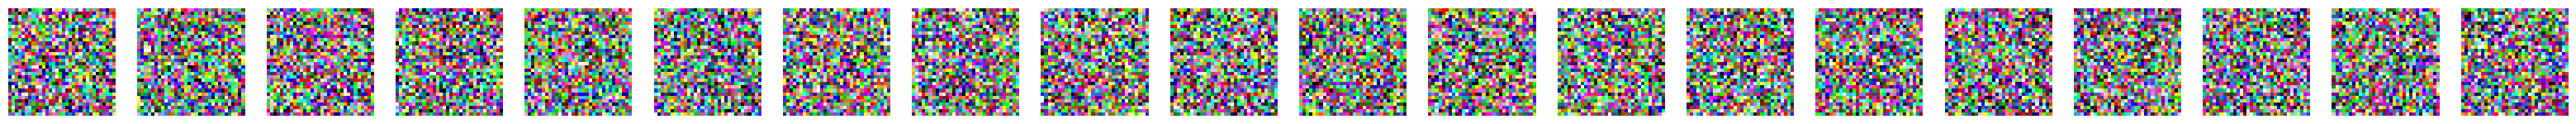

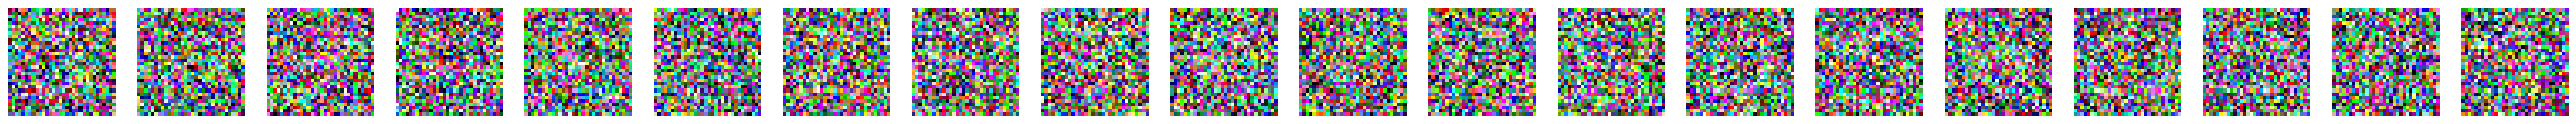

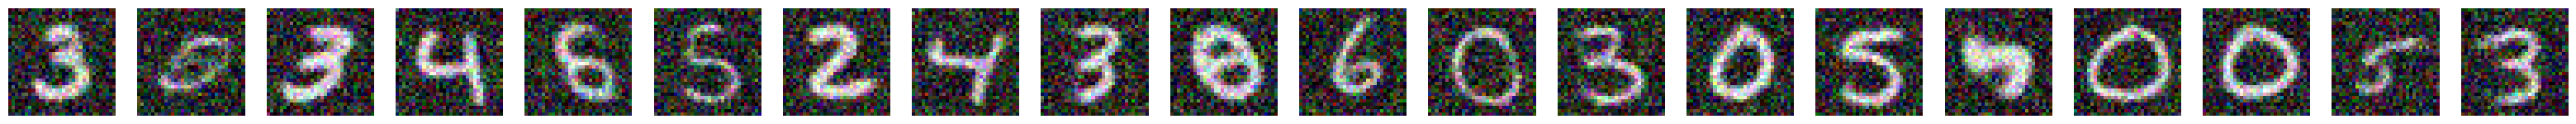

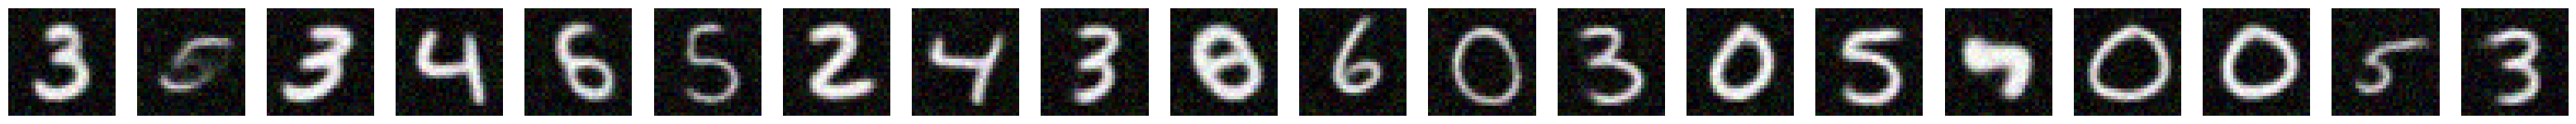

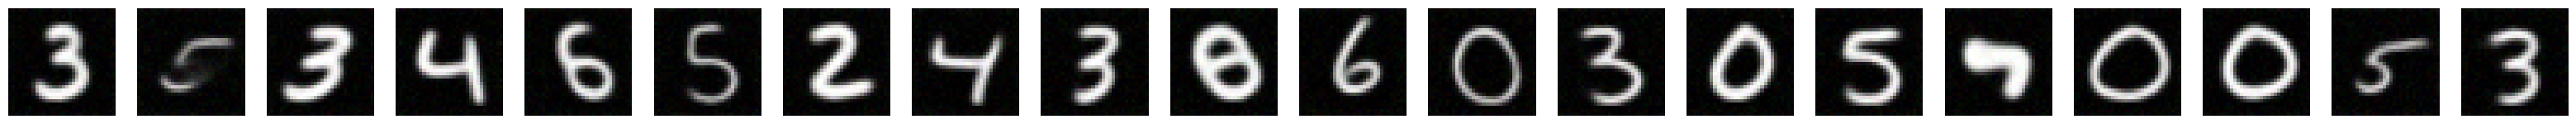

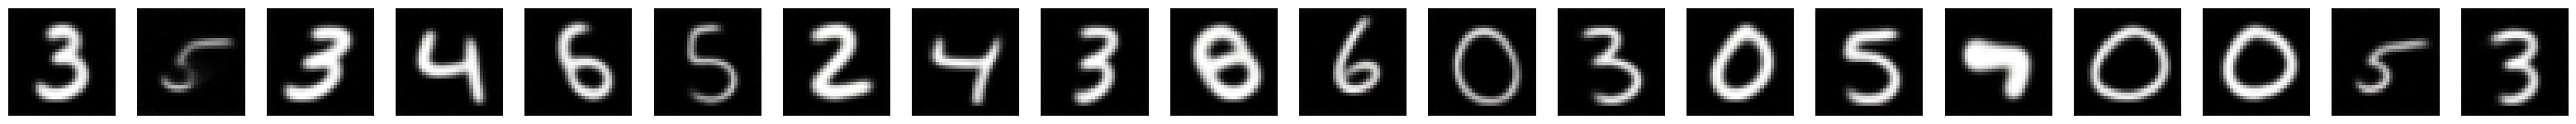

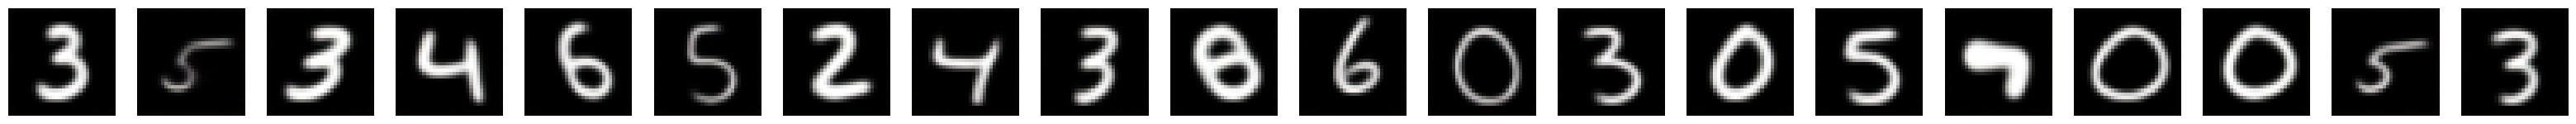

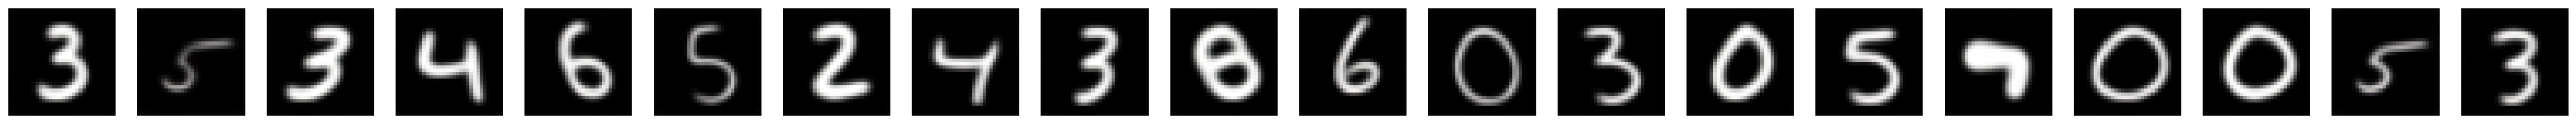

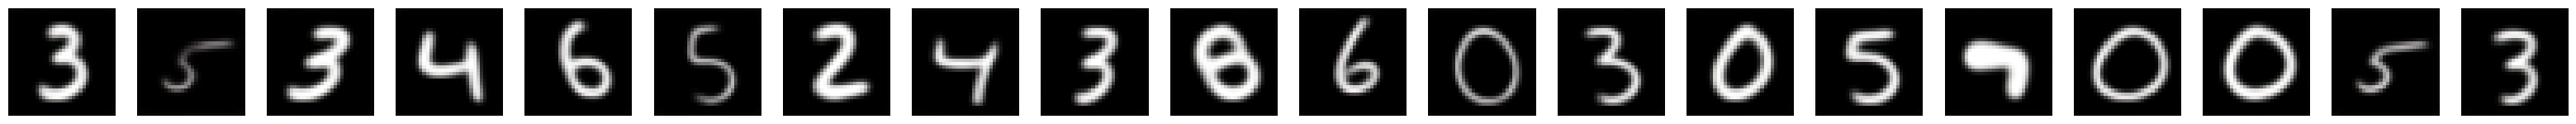

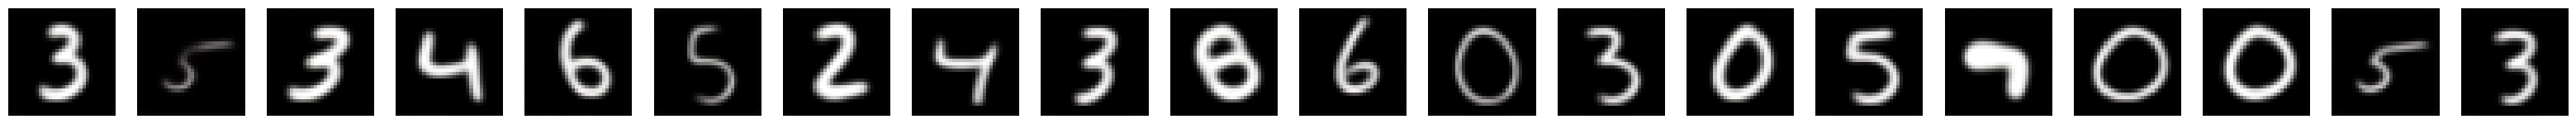

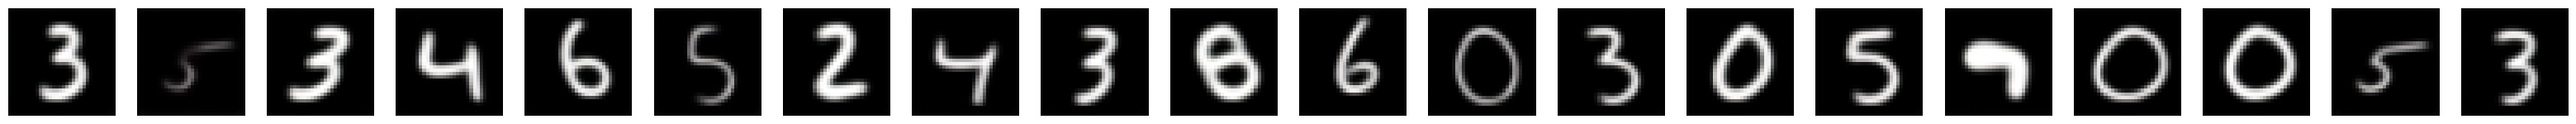

In [57]:
B_plot_from = 0
B_plot_to = 20
for i, x_i in enumerate(trajectory):
    x = (x_i[B_plot_from:B_plot_to].cpu().permute(0, 2, 3, 1) * 0.5 + 0.5).clamp(0, 1)
    fig, axs = plt.subplots(ncols=x.shape[0], figsize=(x.shape[0] * 2, 2))
    for j in range(x.shape[0]):
        axs[j].imshow(x[j])
        axs[j].axis("off")
    plt.show()
#fig, axs = plt.subplots(ncols=x.shape[0], figsize=(x.shape[0] * 2, 2))
#x = (x_data.cpu().permute(0, 2, 3, 1) * 0.5 + 0.5).clamp(0, 1)
#for j in range(x.shape[0]):
#    axs[j].imshow(x[j])
#    axs[j].axis("off")
#plt.show()